In [19]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
import joblib

In [3]:
df = pd.read_csv('Data/acetylcholinesterase_03_bioactivity_data_3class_pIC50_pubchem_fp.csv')
df.head()

,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,PubchemFP9,...,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880,pIC50
0,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,6.124939
1,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,7.000000
2,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,4.301030
3,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,6.522879
4,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,6.096910


In [4]:
x = df.drop(columns= ['pIC50'])
y = df['pIC50']

In [5]:
def remove_low_variance(input_data, threshold = 0.1):
    selection = VarianceThreshold(threshold= threshold)
    selection.fit(input_data)
    return input_data[input_data.columns[selection.get_support(indices= True)]]

x = remove_low_variance(x)
x

,PubchemFP2,PubchemFP3,PubchemFP12,PubchemFP13,PubchemFP15,PubchemFP16,PubchemFP19,PubchemFP20,PubchemFP33,PubchemFP37,...,PubchemFP761,PubchemFP776,PubchemFP777,PubchemFP779,PubchemFP797,PubchemFP798,PubchemFP818,PubchemFP819,PubchemFP821,PubchemFP824
0,1,0,1,0,1,1,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,1,0,1,0,1,1,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
2,0,0,1,0,1,1,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
3,1,0,1,0,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,1,1,1,0,1,0,...,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7169,0,0,0,0,1,1,1,0,1,1,...,0,0,0,0,0,0,0,0,0,0
7170,0,0,1,0,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
7171,1,0,1,0,1,1,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
7172,1,0,1,0,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [6]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state= 42)

In [7]:
# Instantiate the model
rf = RandomForestRegressor(random_state=0, n_jobs= -1)

#Assign a dict of hyperparameters to search over
cv_params = {'n_estimators':[300,500],
            'max_depth':[None,10,20],
            'max_features':['sqrt',0.3,0.5],
            'min_samples_split':[2,5],
            'min_samples_leaf':[1,2],
            'max_samples':[0.7,0.9]
             }

# Assign a dictionary of scoring metrics to capture
scoring = {
    'r2': 'r2',
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error'
}

#Instantiate grid search
rf1 = GridSearchCV(rf, cv_params, scoring= scoring, cv= 4, refit= "r2", n_jobs= 1)

In [ ]:
# %%time
# rf1.fit(x_train, y_train)

CPU times: total: 2h 25min 10s
Wall time: 45min 25s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 0.3, ...], 'max_samples': [0.7, 0.9], 'min_samples_leaf': [1, 2], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'mae': 'neg_mean_absolute_error', 'r2': 'r2', 'rmse': 'neg_root_mean_squared_error'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"verbose verbose: intControls the verbosity: 

In [ ]:
# joblib.dump(rf1,"Streamlit/QSAR_regression.pkl") #Saves one time

['Streamlit/QSAR_regression.pkl']

In [10]:
rf1 = joblib.load("Streamlit/QSAR_regression.pkl")

In [11]:
rf1.best_score_

np.float64(0.4769884164890048)

In [13]:
rf1.best_params_

{'max_depth': None,
 'max_features': 0.5,
 'max_samples': 0.9,
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'n_estimators': 500}

In [14]:
cv_results = pd.DataFrame(rf1.cv_results_)
cv_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_max_features,param_max_samples,param_min_samples_leaf,param_min_samples_split,param_n_estimators,...,mean_test_mae,std_test_mae,rank_test_mae,split0_test_rmse,split1_test_rmse,split2_test_rmse,split3_test_rmse,mean_test_rmse,std_test_rmse,rank_test_rmse
0,2.194468,0.303209,0.173436,0.058182,None,sqrt,0.7,1,2,300,...,-0.812284,0.007418,76,-1.118306,-1.121406,-1.173320,-1.136614,-1.137412,0.021859,70
1,3.944546,0.087216,0.223590,0.017220,None,sqrt,0.7,1,2,500,...,-0.811645,0.006994,75,-1.120073,-1.120525,-1.171815,-1.134076,-1.136622,0.021083,68
2,1.365697,0.033879,0.126243,0.003055,None,sqrt,0.7,1,5,300,...,-0.819298,0.009098,78,-1.117536,-1.120025,-1.178036,-1.130876,-1.136619,0.024433,67
3,2.298815,0.052080,0.199865,0.012036,None,sqrt,0.7,1,5,500,...,-0.818833,0.009202,77,-1.118183,-1.118631,-1.178351,-1.129386,-1.136138,0.024781,64
4,1.327565,0.026141,0.138699,0.020174,None,sqrt,0.7,2,2,300,...,-0.832736,0.009292,90,-1.126844,-1.130550,-1.188413,-1.144877,-1.147671,0.024467,104
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,10.055376,0.116047,0.216185,0.021721,20,0.5,0.9,1,5,500,...,-0.796876,0.008938,2,-1.118035,-1.121854,-1.137370,-1.116247,-1.123376,0.008329,8
140,5.814668,0.051115,0.140330,0.014642,20,0.5,0.9,2,2,300,...,-0.797870,0.009176,6,-1.115303,-1.120583,-1.140969,-1.113754,-1.122652,0.010874,4
141,9.781054,0.140682,0.236497,0.031552,20,0.5,0.9,2,2,500,...,-0.797565,0.008504,4,-1.115729,-1.119610,-1.139240,-1.114595,-1.122294,0.009959,3
142,5.449913,0.040813,0.142306,0.000575,20,0.5,0.9,2,5,300,...,-0.798417,0.007826,11,-1.117307,-1.121419,-1.139877,-1.115143,-1.123436,0.009756,9


In [15]:
def show_train_results(model_name:str, model_object, metric:str):
    '''
    Arguments:
        model_name (string): what you want the model to be called in the output table
        model_object: a fit GridSearchCV object
        metric (string): R2, RMSE and MAE
  
    Returns a pandas df with the R2, RMSE and MAE scores for the model with the best mean 'metric' score across 
    all validation folds.  
    '''

    # Create dictionary that maps input metric to actual metric name in GridSearchCV
    metric_dict = {
    'r2': 'mean_test_r2',
    'mae': 'mean_test_mae',
    'rmse': 'mean_test_rmse'
    }

    # Get all the results from the CV and put them in a df
    cv_results = pd.DataFrame(model_object.cv_results_)

    # Isolate the row of the df with the max(metric) score
    best_estimator_results = cv_results.iloc[cv_results[metric_dict[metric]].idxmax(), :]

    # Extract Accuracy, precision, recall, and f1 score from that row
    r2 = best_estimator_results.mean_test_r2
    mae = -best_estimator_results.mean_test_mae
    rmse = -best_estimator_results.mean_test_rmse

    #NOTE: GridSearchCV always assumes: Higher score = Better. But for error metrics: Lower is better
    #To make them compatible with GridSearchCV, Scikit-Learn internally negates them.
  
    # Create table of results
    table = pd.DataFrame()
    table = pd.DataFrame({'Model': [model_name],
                          'R2': [r2],
                          'MAE': [mae],
                          'RMSE': [rmse],
                        })
  
    return table

In [16]:
show_train_results('QSAR_RFR', rf1, 'r2')

,Model,R2,MAE,RMSE
0,QSAR_RFR,0.476988,0.796815,1.121492


In [20]:
def show_test_scores(model_name:str, model, X_test_data, y_test_data):
    '''
    Generate a table of test scores.

    In: 
        model_name (string):  How you want your model to be named in the output table
        model:                A fit GridSearchCV object
        X_test_data:          numpy array of X_test data
        y_test_data:          numpy array of y_test data

    Out: pandas df of R2, RMSE and MAE scores for your model
    '''

    preds = model.best_estimator_.predict(X_test_data)

    r2 = r2_score(y_test_data, preds)
    mae = mean_absolute_error(y_test_data, preds)
    rmse = root_mean_squared_error(y_test_data, preds)

    table = pd.DataFrame({'Model': [model_name],
                          'R2': [r2],
                          'MAE': [mae],
                          'RMSE': [rmse],
                        })
  
    return table

In [21]:
show_test_scores('QSAR_RFR', rf1, x_test, y_test)

,Model,R2,MAE,RMSE
0,QSAR_RFR,0.492375,0.754994,1.089069


In [22]:
best_rf = rf1.best_estimator_
y_preds = best_rf.predict(x_test)

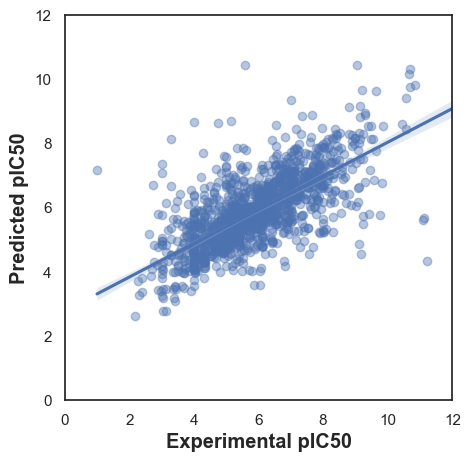

In [23]:
sns.set(color_codes=True)
sns.set_style("white")

ax = sns.regplot(x= y_test, y= y_preds, scatter_kws={'alpha':0.4})
ax.set_xlabel('Experimental pIC50', fontsize='large', fontweight='bold')
ax.set_ylabel('Predicted pIC50', fontsize='large', fontweight='bold')
ax.set_xlim(0, 12)
ax.set_ylim(0, 12)
ax.figure.set_size_inches(5, 5)
plt.show()